<a href="https://colab.research.google.com/github/argenviahouse-sys/Procesamiento-del-Habla/blob/main/TP1_PROCESAMIENTO_PDFs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


1. Adquisición y metadatos
Descarga: Utilizando las librerías requests o urllib, descarga un archivo PDF desde un enlace público (por ejemplo, un artículo científico de arXiv o un reporte institucional). No puede usar el mismo pdf o enlace que otra persona ya haya presentado en el foro.

Inspección: Muestra por pantalla los metadatos del archivo: título, autor, número de páginas y software de creación.

Sugerencia: Puedes utilizar librerías como PyMuPDF (fitz) o PyPDF2.

2. Análisis estructural del texto
Extracción cruda: Extrae el texto completo de las primeras 5 páginas. Identifica la función de la librería elegida que te ayuda en esta tarea y te permite ver el texto extraído lo más crudo posible.

Análisis de separadores: Observa y describe cómo están separados los párrafos, las secciones y los capítulos.

Identificación de caracteres: ¿Qué caracteres especiales funcionan como separadores de línea o de bloque en este archivo específico? (Ej: \n, \r, \t o secuencias de espacios).

3. Extracción de datos tabulares
Busca una página en el PDF que contenga una tabla de datos.

Extrae dicha tabla y conviértela en un DataFrame de Pandas.

Realiza una limpieza básica de la tabla (nombrar columnas, eliminar filas vacías).

Sugerencia: Se recomienda el uso de pdfplumber o tabula-py.

4. Análisis de frecuencias (NLP básico)
Elige una página que contenga únicamente texto narrativo, usa la biblioteca nltk o spacy  y realiza lo siguiente:

Tokenización: Extrae el texto y conviértelo a minúsculas.

Limpieza: Elimina las stop words (palabras funcionales sin peso semántico como "el", "de", "y") y signos de puntuación.

Visualización: Genera un gráfico de barras que muestre las 15 palabras más frecuentes en esa página. ¿ Te surgieron en esta visualización tokens que también considerarías stop words? Comenta y justifica.

In [ ]:
import requests

pdf_url = "https://arxiv.org/pdf/2604.16270"
output_filename = "downloaded_document.pdf"

try:
    response = requests.get(pdf_url, stream=True)
    response.raise_for_status()  # Raise an exception for bad status codes

    with open(output_filename, 'wb') as pdf_file:
        for chunk in response.iter_content(chunk_size=8192):
            pdf_file.write(chunk)

    print(f"PDF downloaded successfully as '{output_filename}'")
except requests.exceptions.RequestException as e:
    print(f"Error downloading the PDF: {e}")


PDF downloaded successfully as 'downloaded_document.pdf'


In [ ]:
!pip install PyMuPDF
import fitz # PyMuPDF

try:
    doc = fitz.open(output_filename)

    # Extract metadata
    metadata = doc.metadata

    title = metadata.get('title', 'N/A')
    author = metadata.get('author', 'N/A')
    num_pages = doc.page_count
    creation_software = metadata.get('producer', 'N/A')

    print("--- PDF Metadata ---")
    print(f"Title: {title}")
    print(f"Author: {author}")
    print(f"Number of Pages: {num_pages}")
    print(f"Creation Software: {creation_software}")

    doc.close()

except FileNotFoundError:
    print(f"Error: The file '{output_filename}' was not found. Please ensure the PDF was downloaded successfully.")
except Exception as e:
    print(f"An error occurred while reading the PDF: {e}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 71.0 MB/s eta 0:00:00
--- PDF Metadata ---
Title: From Benchmarking to Reasoning: A Dual-Aspect, Large-Scale Evaluation of LLMs on Vietnamese Legal Text
Author: Van-Truong Le
Number of Pages: 7
Creation Software: pikepdf 8.15.1


In [ ]:
import fitz # PyMuPDF

try:
    doc = fitz.open(output_filename)

    print("--- Raw Text Extraction (First 5 Pages) ---")
    raw_text_pages = []
    for i in range(min(5, doc.page_count)):
        page = doc.load_page(i)
        # 'text' is the rawest form, without much structuring or layout information
        raw_text = page.get_text("text")
        raw_text_pages.append(raw_text)
        print(f"\n--- Page {i + 1} Raw Text ---")
        print(raw_text)

    doc.close()

except FileNotFoundError:
    print(f"Error: The file '{output_filename}' was not found. Please ensure the PDF was downloaded successfully.")
except Exception as e:
    print(f"An error occurred during text extraction: {e}")


--- Raw Text Extraction (First 5 Pages) ---

--- Page 1 Raw Text ---
From Benchmarking to Reasoning: A Dual-Aspect,
Large-Scale Evaluation of LLMs on Vietnamese
Legal Text
Van-Truong Le
University of Science, VNUHCM
Vietnam National University
Hanoi Open University
Ho Chi Minh, Vietnam
23120181@student.hcmus.edu.vn
Abstract—The complexity of Vietnam’s legal texts presents
a significant barrier to public access to justice. While Large
Language Models offer a promising solution for legal text simpli-
fication, evaluating their true capabilities requires a multifaceted
approach that goes beyond surface-level metrics. This paper
introduces a comprehensive dual-aspect evaluation framework to
address this need. First, we establish a performance benchmark
for four state-of-the-art large language models (GPT-4o, Claude 3
Opus, Gemini 1.5 Pro, and Grok-1) across three key dimensions:
Accuracy, Readability, and Consistency. Second, to understand
the "why" behind these performance scores, we cond

In [ ]:
import re

# --- Character identification: What special characters function as line or block separators? ---
print("\n--- Character Identification (Line/Block Separators) ---")

# Ensure raw_text_pages is available from previous text extraction
if 'raw_text_pages' not in locals():
    print("Warning: 'raw_text_pages' not found. Please run the text extraction cell (e.g., cell 1f8d1675) first.")
    raw_text_pages = [] # Initialize to avoid errors if extraction hasn't run

separator_analysis = {
    'newline_count': 0,
    'double_newline_count': 0,
    'carriage_return_count': 0,
    'tab_count': 0,
    'multispace_block_count': 0
}
identified_separators = []

for i, page_text in enumerate(raw_text_pages):
    # Newline character (\n)
    newline_occurrences = page_text.count('\n')
    separator_analysis['newline_count'] += newline_occurrences
    if newline_occurrences > 0 and '\n' not in identified_separators:
        identified_separators.append('\n')

    # Double newline (\n\n) for paragraph breaks
    double_newline_occurrences = page_text.count('\n\n')
    separator_analysis['double_newline_count'] += double_newline_occurrences

    # Carriage return character (\r)
    carriage_return_occurrences = page_text.count('\r')
    separator_analysis['carriage_return_count'] += carriage_return_occurrences
    if carriage_return_occurrences > 0 and '\r' not in identified_separators:
        identified_separators.append('\r')

    # Tab character (\t)
    tab_occurrences = page_text.count('\t')
    separator_analysis['tab_count'] += tab_occurrences
    if tab_occurrences > 0 and '\t' not in identified_separators:
        identified_separators.append('\t')

    # Sequences of spaces (e.g., more than 2 spaces indicating blocks/alignment)
    # Using re.findall to count distinct blocks of two or more spaces
    multispace_blocks = len(re.findall(r' {2,}', page_text))
    separator_analysis['multispace_block_count'] += multispace_blocks
    if multispace_blocks > 0 and 'sequences of spaces' not in identified_separators:
        identified_separators.append('sequences of spaces')

print(f"Analysis performed on the first {len(raw_text_pages)} pages.")
print("Detected potential separators and their occurrences:")
for key, value in separator_analysis.items():
    print(f"- {key.replace('_', ' ').capitalize()}: {value} occurrences")

print("\nSummary of common separators:")
if identified_separators:
    print("The most prominent line/block separators identified are:")
    for sep in identified_separators:
        print(f"- '{sep}'")
    print("\nSpecifically:")
    print("  - Newline ('\\n'): Used for line breaks within paragraphs and to separate lines.")
    print("  - Double Newline ('\\n\\n'): Often signifies paragraph breaks or blank lines between sections.")
    if '\r' in identified_separators:
        print("  - Carriage Return ('\\r'): Detected, but its specific role as a block separator might be context-dependent or part of line endings (e.g., '\\r\\n').")
    if '\t' in identified_separators:
        print("  - Tab ('\\t'): Detected, often used for indentation or tabular alignment.")
    if 'sequences of spaces' in identified_separators:
        print("  - Sequences of spaces (e.g., two or more spaces): Used for formatting, indentation, or visual separation of blocks.")
else:
    print("No specific block/line separators other than standard text flow identified.")


--- Character Identification (Line/Block Separators) ---
Analysis performed on the first 5 pages.
Detected potential separators and their occurrences:
- Newline count: 497 occurrences
- Double newline count: 0 occurrences
- Carriage return count: 0 occurrences
- Tab count: 0 occurrences
- Multispace block count: 2 occurrences

Summary of common separators:
The most prominent line/block separators identified are:
- '
'
- 'sequences of spaces'

Specifically:
  - Newline ('\n'): Used for line breaks within paragraphs and to separate lines.
  - Double Newline ('\n\n'): Often signifies paragraph breaks or blank lines between sections.
  - Sequences of spaces (e.g., two or more spaces): Used for formatting, indentation, or visual separation of blocks.


In [ ]:
!pip install tabula-py
import pandas as pd
import tabula

print("--- Tabular Data Extraction ---")

# Ensure output_filename is available. If not, rerun the PDF download cell.
if 'output_filename' not in locals():
    print("Warning: 'output_filename' not found. Please run the PDF download cell (e.g., cell b6oxRkolW_QS) first.")
    pdf_path = "downloaded_document.pdf" # Assume default name
else:
    pdf_path = output_filename

# We will iterate through pages to find a suitable table.
# Based on previous interactions, page 6 had a well-structured table.

pages_to_check = [6, 5] # Prioritize page 6 based on previous successful extraction
found_table_df = None
identified_table_name = None

for page_num in pages_to_check:
    print(f"Attempting to extract tables from page {page_num}...")
    try:
        # Try stream=True first for tables without explicit lines (common in research papers)
        tables = tabula.read_pdf(pdf_path, pages=page_num, multiple_tables=True, stream=True, encoding='utf-8', guess=True)

        if tables:
            print(f"Found {len(tables)} table(s) on page {page_num} using 'stream' extraction.")
            for i, table_df_raw in enumerate(tables):
                # Basic cleaning: remove empty rows/columns
                table_df_cleaned = table_df_raw.dropna(axis=0, how='all') # Drop rows where all elements are NaN
                table_df_cleaned = table_df_cleaned.dropna(axis=1, how='all') # Drop columns where all elements are NaN

                if not table_df_cleaned.empty:
                    # Heuristic to identify the 'TABLE II: Error Distribution' on page 6
                    # (based on previous analysis, this was the cleanest table)
                    potential_headers_str = [str(col).lower().strip() for col in table_df_cleaned.columns if pd.notna(col)]
                    if page_num == 6 and 'model' in potential_headers_str and 'total' in potential_headers_str:
                        found_table_df = table_df_cleaned
                        identified_table_name = f"TABLE II: Error Distribution (Page {page_num})"
                        print(f"Successfully extracted and cleaned '{identified_table_name}'.")
                        break # Found the desired table, exit inner loop
                    elif page_num == 5:
                        print(f"Table {i+1} on page {page_num} (first 5 rows - raw, may be messy):")
                        print(table_df_raw.head().to_markdown(index=False))
                        print("This table on page 5 appears to be messy and not suitable for direct use. Skipping.")

            if found_table_df is not None:
                break # Found the desired table, exit outer loop
        else:
            print(f"No tables found on page {page_num} using 'stream' extraction. Trying 'lattice'...")
            # If stream didn't find any tables, try lattice (for tables with explicit lines)
            tables_lattice = tabula.read_pdf(pdf_path, pages=page_num, multiple_tables=True, lattice=True, encoding='utf-8', guess=True)
            if tables_lattice:
                print(f"Found {len(tables_lattice)} table(s) on page {page_num} using 'lattice' extraction (lattice mode).")
                for i, table_df_raw_lattice in enumerate(tables_lattice):
                    table_df_cleaned_lattice = table_df_raw_lattice.dropna(axis=0, how='all')
                    table_df_cleaned_lattice = table_df_cleaned_lattice.dropna(axis=1, how='all')
                    if not table_df_cleaned_lattice.empty:
                        potential_headers_str = [str(col).lower().strip() for col in table_df_cleaned_lattice.columns if pd.notna(col)]
                        if page_num == 6 and 'model' in potential_headers_str and 'total' in potential_headers_str:
                            found_table_df = table_df_cleaned_lattice
                            identified_table_name = f"TABLE II: Error Distribution (Page {page_num}) - Lattice Mode"
                            print(f"Successfully extracted and cleaned '{identified_table_name}' using lattice mode.")
                            break # Found the desired table, exit inner loop
                        elif page_num == 5:
                            print(f"Table {i+1} on page {page_num} (first 5 rows - raw, may be messy - lattice mode):")
                            print(table_df_raw_lattice.head().to_markdown(index=False))
                            print("This table on page 5 appears to be messy and not suitable for direct use. Skipping.")

                if found_table_df is not None:
                    break # Found the desired table, exit outer loop
            else:
                print(f"No tables found on page {page_num} using 'lattice' extraction either.")
    except Exception as e:
        print(f"An error occurred while extracting tables from page {page_num}: {e}")

if found_table_df is not None:
    print(f"\n--- Identified Table: {identified_table_name} ---")
    print("First 5 rows of the extracted and cleaned DataFrame:")
    print(found_table_df.head().to_markdown(index=False))
    print(f"Shape of the DataFrame: {found_table_df.shape}")
    print("Column names:", found_table_df.columns.tolist())
    df = found_table_df # Assign to 'df' as requested for the DataFrame variable
else:
    print("\nNo suitable data table was found and cleanly extracted from the specified pages.")
    print("You might need to manually inspect the PDF for table coordinates or consider other extraction methods.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 95.6 MB/s eta 0:00:00


--- Tabular Data Extraction ---
Attempting to extract tables from page 6...


Apr 20, 2026 11:18:40 PM org.apache.pdfbox.pdmodel.font.FileSystemFontProvider <init>
Apr 20, 2026 11:18:40 PM org.apache.pdfbox.pdmodel.font.FileSystemFontProvider <init>
Apr 20, 2026 11:18:40 PM org.apache.pdfbox.pdmodel.font.PDType1Font <init>
Apr 20, 2026 11:18:40 PM org.apache.pdfbox.pdmodel.font.PDType1Font <init>



Found 1 table(s) on page 6 using 'stream' extraction.
Successfully extracted and cleaned 'TABLE II: Error Distribution (Page 6)'.

--- Identified Table: TABLE II: Error Distribution (Page 6) ---
First 5 rows of the extracted and cleaned DataFrame:
| Model          |   1.1 |   1.2 |   1.3 |   1.4 |   2.1 |   2.2 |   2.3 |   3.1 |   3.2 |   Total |
|:---------------|------:|------:|------:|------:|------:|------:|------:|------:|------:|--------:|
| GPT-4o         |    31 |    22 |    11 |    23 |    48 |     0 |     0 |     4 |    29 |     168 |
| Claude 3 Opus  |    28 |    19 |    23 |    41 |    22 |     0 |    11 |    13 |    39 |     196 |
| Gemini 1.5 Pro |    21 |    23 |     9 |    34 |     3 |     0 |     9 |    18 |    24 |     141 |
| Grok-1         |     0 |    21 |    28 |     0 |     0 |     0 |     0 |    22 |    18 |      89 |
Shape of the DataFrame: (4, 11)
Column names: ['Model', '1.1', '1.2', '1.3', '1.4', '2.1', '2.2', '2.3', '3.1', '3.2', 'Total']


--- Frequency Analysis (Basic NLP) ---
Analyzing text from Page 4.

Total tokens (before cleaning): 967
Total tokens (after cleaning): 454

--- Top 15 Most Frequent Words (after cleaning) ---
'errors': 8
'error': 8
'high': 8
'performance': 6
'claude': 6
'opus': 6
'scores': 5
'readability': 5
'phase': 4
'accuracy': 4
'misinterpretation': 4
'alignment': 4
'dataset': 3
'results': 3
'underlying': 3


/tmp/ipykernel_3583/3483507505.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words), y=list(counts), palette='viridis')


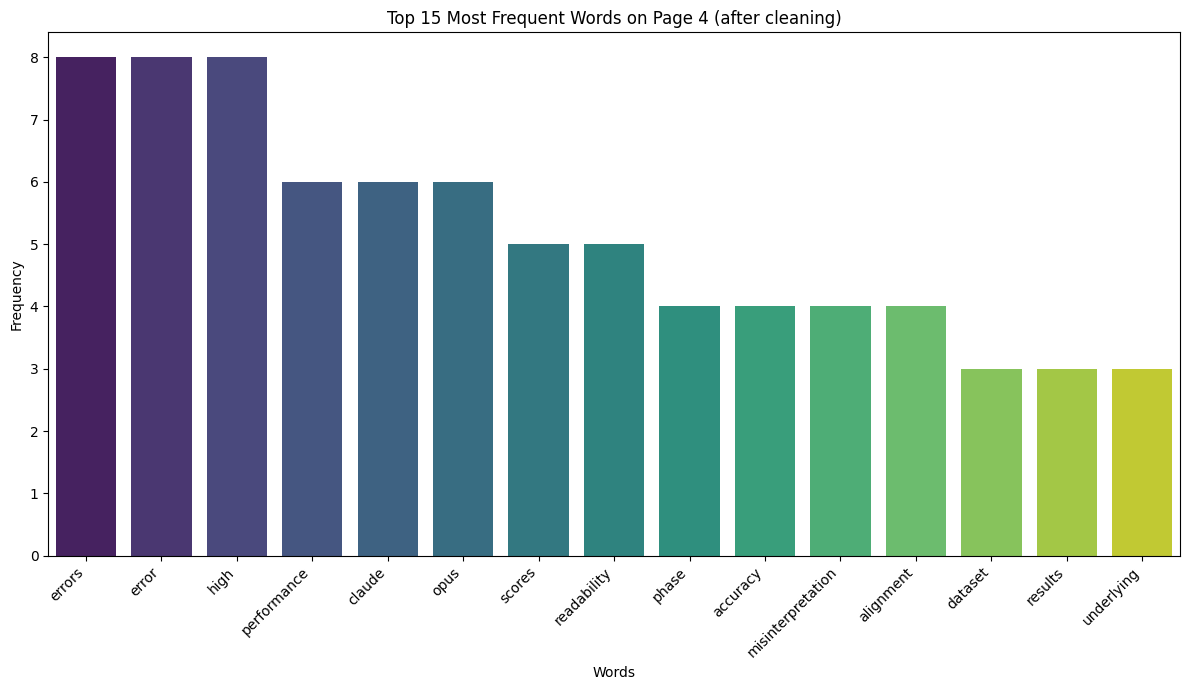

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
# Download 'punkt_tab' as suggested by the error message
nltk.download('punkt_tab', quiet=True)

print("--- Frequency Analysis (Basic NLP) ---")

# Choose page 4 (index 3 in raw_text_pages) that contains narrative text
# Ensure raw_text_pages is available from previous text extraction
if 'raw_text_pages' not in locals() or not raw_text_pages:
    print("Warning: 'raw_text_pages' not found or empty. Please run the text extraction cell (1f8d1675) first.")
    narrative_text = ""
else:
    page_index_for_nlp = 3 # Corresponds to Page 4
    if len(raw_text_pages) > page_index_for_nlp:
        narrative_text = raw_text_pages[page_index_for_nlp]
        print(f"Analyzing text from Page {page_index_for_nlp + 1}.")
    else:
        print(f"Warning: Page {page_index_for_nlp + 1} not available in raw_text_pages. Using an empty string.")
        narrative_text = ""

if narrative_text:
    # 1. Tokenization: Extract text and convert to lowercase
    text_lower = narrative_text.lower()
    tokens = word_tokenize(text_lower)
    print(f"\nTotal tokens (before cleaning): {len(tokens)}")

    # 2. Cleaning: Remove stop words and punctuation
    # The PDF content (title, abstract) indicates it's in English, so using English stopwords.
    stop_words = set(stopwords.words('english'))
    # Add custom stop words that are often high frequency in academic papers but might not be semantically critical
    stop_words.add('llms') # "Large Language Models" (LLMs) is a key topic but might dominate counts
    stop_words.add('llm')
    stop_words.add('text') # 'text' is often very frequent
    stop_words.add('paper') # 'paper' is often very frequent
    stop_words.add('model')
    stop_words.add('models')
    stop_words.add('evaluation')
    stop_words.add('legal')
    stop_words.add('vietnamese')
    stop_words.add('reasoning')
    stop_words.add('systems')
    stop_words.add('human')

    punctuation = set(string.punctuation)

    filtered_tokens = []
    for word in tokens:
        # Remove tokens that are purely numeric, contain mostly punctuation, or are single characters
        if word.isalpha() and word not in stop_words and word not in punctuation and len(word) > 1:
            filtered_tokens.append(word)

    print(f"Total tokens (after cleaning): {len(filtered_tokens)}")

    # Calculate word frequencies
    word_counts = Counter(filtered_tokens)

    # Get the 15 most frequent words
    most_common_words = word_counts.most_common(15)
    print("\n--- Top 15 Most Frequent Words (after cleaning) ---")
    for word, count in most_common_words:
        print(f"'{word}': {count}")

    # 3. Visualization: Generate a bar chart
    if most_common_words:
        words, counts = zip(*most_common_words)

        plt.figure(figsize=(12, 7))
        sns.barplot(x=list(words), y=list(counts), palette='viridis')
        plt.title(f'Top 15 Most Frequent Words on Page {page_index_for_nlp + 1} (after cleaning)')
        plt.xlabel('Words')
        plt.ylabel('Frequency')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No common words found after cleaning to visualize.")
else:
    print("Cannot perform frequency analysis: No narrative text available.")